# Regresión lineal simple con OLS: ejemplo completo de precios de viviendas

Este notebook cierra el bloque teórico con un caso aplicado y reproducible. Utiliza un problema realista, predecir el precio de una vivienda a partir de su superficie, pero genera los datos mediante simulación. Esto permite conocer los coeficientes poblacionales $\beta_0$ y $\beta_1$ y compararlos con sus estimaciones $\widehat\beta_0$ y $\widehat\beta_1$, algo que no es posible con datos reales.

El recorrido incluye:

1. notación de regresión y construcción de los datos;
2. residuos y función objetivo RSS;
3. cálculo manual y ajuste con `LinearRegression`;
4. geometría de RSS en el espacio de coeficientes;
5. propiedades de los residuos con intercepto;
6. comparación con un ajuste sin intercepto;
7. partición *holdout*, entrenamiento y evaluación en test;
8. gráficos de residuos y detección de una relación no lineal;
9. predicción para una vivienda nueva.

> **Convención:** utilizamos **RSS** (*residual sum of squares*) para $\sum_i r_i^2$.

## 1. Notación

Para cada vivienda $i$ observamos un predictor $x_i$ y un target cuantitativo $y_i$:

$$
(x_i,y_i), \qquad i=1,\ldots,n.
$$

En este ejemplo:

- $x_i$: superficie de la vivienda, en m²;
- $y_i$: precio observado, en miles de euros (k€).

En la notación general del curso, $\mathbf{x}_i$ es un vector de predictores. Aquí contiene una sola característica, por lo que lo escribimos como el escalar $x_i$.

La relación poblacional utilizada para generar los datos es:

$$
Y_i=\beta_0+\beta_1X_i+\varepsilon_i.
$$

| Símbolo | Significado |
|---|---|
| $\beta_0,\beta_1$ | Coeficientes poblacionales, fijos pero normalmente desconocidos |
| $b_0,b_1$ | Valores candidatos considerados al minimizar RSS |
| $\widehat\beta_0,\widehat\beta_1$ | Coeficientes estimados a partir de los datos de entrenamiento |
| $\widehat y_i$ | Predicción del modelo ajustado para la observación $i$ |
| $\varepsilon_i$ | Error poblacional no observable |
| $r_i=y_i-\widehat y_i$ | Residuo observable después del ajuste |

La recta ajustada será:

$$
\widehat y_i=\widehat\beta_0+\widehat\beta_1x_i.
$$

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)


SEED = 7
OUTPUT_DIR = Path("outputs_ols_housing")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BLUE = "#2D6FA3"
ORANGE = "#E69F3A"
PURPLE = "#7B4FA3"
GREEN = "#208A72"
GREY = "#666666"
LIGHT_GREY = "#D9D9D9"
RED = "#B44343"
DARK = "#222222"

plt.rcParams.update({
    "figure.figsize": (9.5, 6.0),
    "figure.dpi": 110,
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelcolor": DARK,
    "axes.titlecolor": DARK,
    "xtick.color": GREY,
    "ytick.color": GREY,
    "text.usetex": False # Changed from True to False
})


def manual_simple_ols(x, y):
    # OLS con intercepto para un único predictor.
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x_bar = x.mean()
    y_bar = y.mean()
    b1_hat = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
    b0_hat = y_bar - b1_hat * x_bar
    return b0_hat, b1_hat


def regression_metrics(y_true, y_pred):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    return {
        "RSS (k€^2)": np.sum(residuals**2),
        "MSE (k€^2)": mean_squared_error(y_true, y_pred),
        "RMSE (k€)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE (k€)": mean_absolute_error(y_true, y_pred),
        "$R^2$": r2_score(y_true, y_pred),
    }

Matplotlib is building the font cache; this may take a moment.


## 2. Datos del ejemplo

Utilizamos la misma configuración que en la animación de minimización de RSS:

$$
Y=15+2.1X+\varepsilon,
\qquad
\varepsilon\sim\mathcal N(0,28^2).
$$

Por tanto, en la población simulada conocemos:

$$
\beta_0=15\ \text{k€},
\qquad
\beta_1=2.1\ \text{k€/m²}.
$$

El ruido hace que las observaciones no se sitúen exactamente sobre la recta poblacional.

In [6]:
rng = np.random.default_rng(SEED)

n = 55
beta_0 = 15.0
beta_1 = 2.1
noise_sd = 28.0

size = rng.uniform(50, 220, n)
epsilon = rng.normal(0, noise_sd, n)
price = beta_0 + beta_1 * size + epsilon

housing = pd.DataFrame({
    "size_m2": size,
    "price_keuro": price,
    "population_error_keuro": epsilon,
})

display(housing.head())
display(housing[["size_m2", "price_keuro"]].describe().round(2))

,size_m2,price_keuro,population_error_keuro
0,156.266229,337.873182,-5.285900
1,202.526346,459.426814,19.121487
2,181.866567,395.057306,-1.862485
3,88.285222,219.081899,18.682932
4,101.028268,267.437996,40.278633


,size_m2,price_keuro
count,55.00,55.00
mean,131.79,290.44
std,48.92,102.87
min,50.63,123.89
25%,92.70,214.64
50%,135.77,287.99
75%,171.87,350.85
max,219.24,493.92


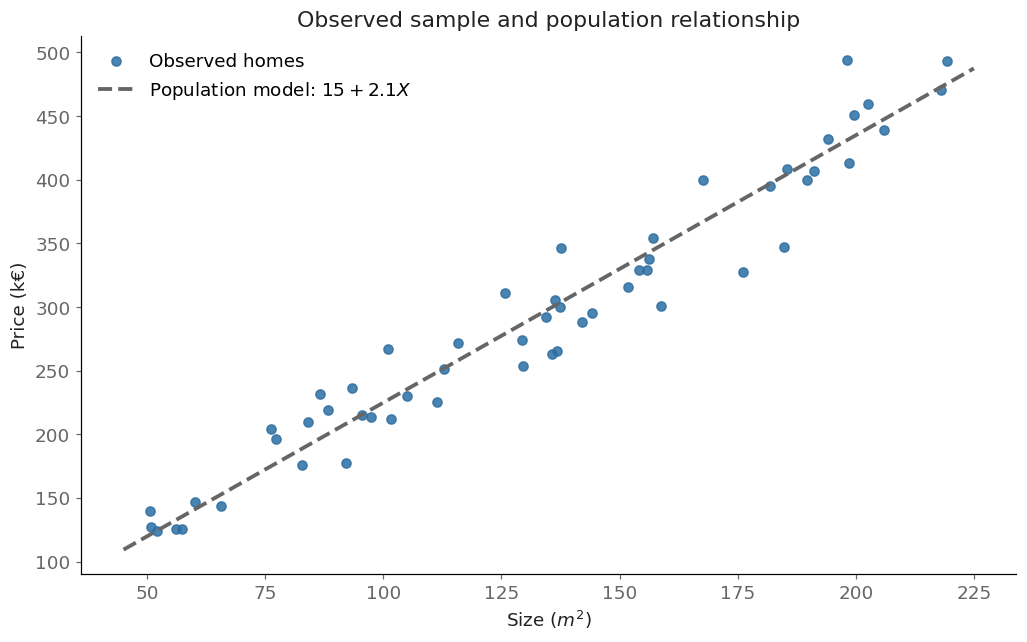

In [7]:
x_grid = np.linspace(45, 225, 250)

fig, ax = plt.subplots()
ax.scatter(housing["size_m2"], housing["price_keuro"], color=BLUE, alpha=0.85,
           label="Observed homes")
ax.plot(x_grid, beta_0 + beta_1 * x_grid, color=GREY, lw=2.5, ls="--",
        label=r"Population model: $15 + 2.1X$")
ax.set(
    title="Observed sample and population relationship",
    xlabel="Size ($m^2$)",
    ylabel="Price (k€)",
)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_sample_and_population.png", dpi=180)
plt.show()

## 3. Cálculo manual de los coeficientes OLS

Para comprender el mecanismo de ajuste, primero utilizamos las 55 observaciones como una muestra de entrenamiento completa. Más adelante repetiremos el proceso con una partición *holdout*.

Los coeficientes que minimizan RSS son:

$$
\widehat\beta_1=
\frac{\sum_{i=1}^{n}(x_i-\bar x)(y_i-\bar y)}
{\sum_{i=1}^{n}(x_i-\bar x)^2},
\qquad
\widehat\beta_0=\bar y-\widehat\beta_1\bar x.
$$

Estas expresiones proceden de las dos condiciones del mínimo:

$$
\frac{\partial RSS}{\partial b_0}=0,
\qquad
\frac{\partial RSS}{\partial b_1}=0.
$$

La primera conduce a $b_0=\bar y-b_1\bar x$. Al sustituir ese resultado en la segunda se obtiene la fórmula de $\widehat\beta_1$ y, después, la de $\widehat\beta_0$.

Los gorros indican que estos coeficientes se han estimado utilizando una muestra. No tienen por qué coincidir exactamente con los valores poblacionales.

In [8]:
x = housing["size_m2"].to_numpy()
y = housing["price_keuro"].to_numpy()

beta0_hat, beta1_hat = manual_simple_ols(x, y)
y_hat = beta0_hat + beta1_hat * x
residuals = y - y_hat
rss = np.sum(residuals**2)

coefficient_table = pd.DataFrame({
    "Quantity": [r"Population $\beta_0$", r"Estimate $\widehat\beta_0$",
                 r"Population $\beta_1$", r"Estimate $\widehat\beta_1$"],
    "Value": [beta_0, beta0_hat, beta_1, beta1_hat],
    "Unit": ["k€", "k€", "k€/m²", "k€/m²"],
})

display(coefficient_table.round(4))
print(f"Minimum RSS = {rss:,.2f} k€²")

,Quantity,Value,Unit
0,Population $\beta_0$,15.0000,k€
1,Estimate $\widehat\beta_0$,21.1260,k€
2,Population $\beta_1$,2.1000,k€/m²
3,Estimate $\widehat\beta_1$,2.0435,k€/m²


Minimum RSS = 31,761.83 k€²


### Comprobación con una implementación de ML

`LinearRegression` aprende los mismos coeficientes. En scikit-learn:

- `intercept_` corresponde a $\widehat\beta_0$;
- `coef_[0]` corresponde a $\widehat\beta_1$;
- `predict()` calcula $\widehat y$ para nuevas entradas.

In [9]:
model_all = LinearRegression(fit_intercept=True)
model_all.fit(x.reshape(-1, 1), y)

comparison = pd.DataFrame({
    "Method": ["Manual formulas", "scikit-learn"],
    "Intercept": [beta0_hat, model_all.intercept_],
    "Slope": [beta1_hat, model_all.coef_[0]],
})
display(comparison.round(8))

assert np.isclose(beta0_hat, model_all.intercept_)
assert np.isclose(beta1_hat, model_all.coef_[0])

,Method,Intercept,Slope
0,Manual formulas,21.126044,2.043461
1,scikit-learn,21.126044,2.043461


## 4. Predicciones, residuos y RSS

Para cada vivienda:

$$
\widehat y_i=\widehat\beta_0+\widehat\beta_1x_i,
\qquad
r_i=y_i-\widehat y_i.
$$

El signo del residuo tiene una interpretación directa:

- $r_i>0$: el precio observado supera la predicción;
- $r_i<0$: el precio observado queda por debajo de la predicción.

OLS minimiza la suma de los residuos al cuadrado:

$$
RSS=\sum_{i=1}^{n}r_i^2.
$$

Como los datos son simulados, también conocemos $\varepsilon_i$, la desviación respecto de la recta poblacional. En un problema real solo observamos el residuo $r_i$, calculado respecto de la recta estimada. Por eso $\varepsilon_i$ y $r_i$ representan conceptos relacionados, pero no son la misma cantidad.

In [10]:
results_all = housing[["size_m2", "price_keuro", "population_error_keuro"]].copy()
results_all["predicted_price_keuro"] = y_hat
results_all["residual_keuro"] = residuals
results_all["squared_residual_keuro2"] = residuals**2

display(results_all.head(10).round(2))
print("La suma de la última columna es RSS:",
      f"{results_all['squared_residual_keuro2'].sum():,.2f} k€²")

,size_m2,price_keuro,population_error_keuro,predicted_price_keuro,residual_keuro,squared_residual_keuro2
0,156.27,337.87,-5.29,340.45,-2.58,6.64
1,202.53,459.43,19.12,434.98,24.45,597.61
2,181.87,395.06,-1.86,392.76,2.29,5.26
3,88.29,219.08,18.68,201.53,17.55,307.95
4,101.03,267.44,40.28,227.57,39.86,1589.19
5,198.50,412.94,-18.92,426.76,-13.82,191.03
6,50.90,127.57,5.69,125.13,2.44,5.95
7,189.61,400.21,-12.97,408.58,-8.38,70.20
8,185.50,408.12,3.56,400.19,7.93,62.82
9,129.55,253.81,-33.24,285.85,-32.04,1026.75


La suma de la última columna es RSS: 31,761.83 k€²


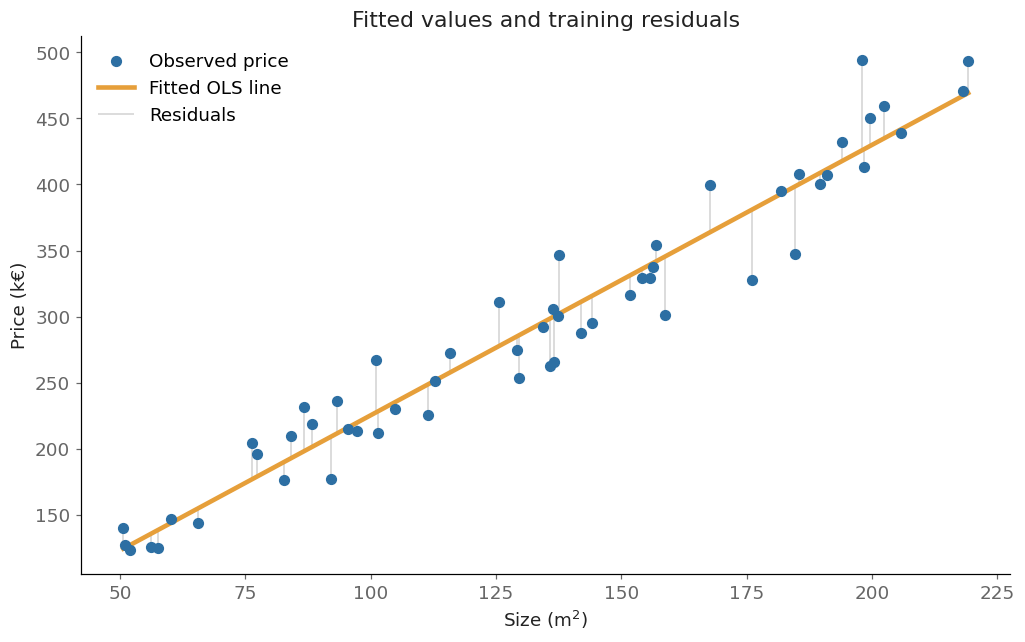

In [11]:
order = np.argsort(x)

fig, ax = plt.subplots()
ax.scatter(x, y, color=BLUE, s=40, label="Observed price", zorder=3)
ax.plot(x[order], y_hat[order], color=ORANGE, lw=3, label="Fitted OLS line", zorder=2)
ax.vlines(x, y_hat, y, color=LIGHT_GREY, lw=1.2, label="Residuals", zorder=1)
ax.set(
    title="Fitted values and training residuals",
    xlabel="Size (m$^{2}$)",
    ylabel="Price (k€)",
)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_fitted_line_and_residuals.png", dpi=180)
plt.show()

## 5. RSS como superficie en el espacio de coeficientes

Cada punto $(b_0,b_1)$ representa una recta candidata diferente. RSS asigna un valor de error a cada una:

$$
(b_0,b_1)\longmapsto RSS(b_0,b_1).
$$

Las curvas de nivel reúnen combinaciones de coeficientes que producen el mismo RSS. El centro de las curvas corresponde a $(\widehat\beta_0,\widehat\beta_1)$.

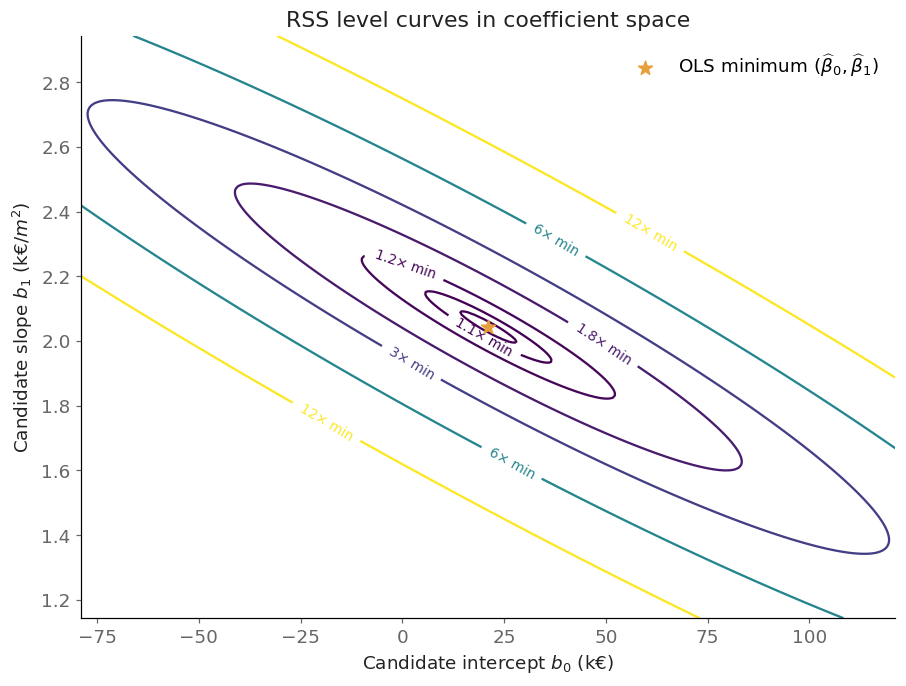

In [12]:
b0_values = np.linspace(beta0_hat - 100, beta0_hat + 100, 260)
b1_values = np.linspace(beta1_hat - 0.9, beta1_hat + 0.9, 260)
B0, B1 = np.meshgrid(b0_values, b1_values)
RSS = np.sum(
    (y[None, None, :] - (B0[:, :, None] + B1[:, :, None] * x[None, None, :])) ** 2,
    axis=2,
)

levels = rss * np.array([1.01, 1.05, 1.2, 1.8, 3.0, 6.0, 12.0])

fig, ax = plt.subplots(figsize=(8.4, 6.4))
contours = ax.contour(B0, B1, RSS, levels=levels, cmap="viridis", linewidths=1.5)
ax.clabel(contours, inline=True, fontsize=9, fmt=lambda value: f"{value/rss:.2g}× min")
ax.scatter(beta0_hat, beta1_hat, color=ORANGE, s=90, marker="*",
           label=r"OLS minimum $(\widehat\beta_0,\widehat\beta_1)$", zorder=5)
ax.set(
    title="RSS level curves in coefficient space",
    xlabel=r"Candidate intercept $b_0$ (k€)",
    ylabel=r"Candidate slope $b_1$ (k€/$m^{2}$)",
)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_rss_contours.png", dpi=180)
plt.show()

## 6. Propiedades de los residuos de entrenamiento

Al minimizar RSS respecto a $b_0$ y $b_1$, OLS obtiene las condiciones:

$$
\frac{\partial RSS}{\partial b_0}=-2\sum_{i=1}^{n}r_i=0,
\qquad
\frac{\partial RSS}{\partial b_1}=-2\sum_{i=1}^{n}x_i r_i=0.
$$

Por tanto, cuando el modelo incluye intercepto:

$$
\sum_i r_i=0,
\qquad
\sum_i(x_i-\bar x)r_i=0.
$$

La primera igualdad evita un exceso o defecto medio de predicción sobre entrenamiento. La segunda elimina una tendencia lineal residual con el predictor utilizado. Son consecuencias del ajuste, no pruebas de que el modelo sea adecuado.

In [13]:
properties = pd.Series({
    "Sum of residuals": residuals.sum(),
    "Mean residual": residuals.mean(),
    "Sum of x_i * r_i": np.sum(x * residuals),
    "Sample covariance Cov(X, r)": np.cov(x, residuals, ddof=1)[0, 1],
    "Mean observed y": y.mean(),
    "Mean fitted y_hat": y_hat.mean(),
    "Prediction at mean x": beta0_hat + beta1_hat * x.mean(),
})
display(properties.to_frame("Value"))

print("Las pequeñas desviaciones respecto de cero son redondeo numérico.")

,Value
Sum of residuals,2.216893e-12
Mean residual,4.030715e-14
Sum of x_i * r_i,2.335128e-10
"Sample covariance Cov(X, r)",-1.118210e-12
Mean observed y,2.904430e+02
Mean fitted y_hat,2.904430e+02
Prediction at mean x,2.904430e+02


Las pequeñas desviaciones respecto de cero son redondeo numérico.


## 7. ¿Qué cambia si eliminamos el intercepto?

Sin intercepto, la familia de modelos queda restringida a:

$$
\widehat y=b_1x.
$$

Todas las rectas candidatas deben pasar por $(0,0)$. OLS continúa minimizando RSS y continúa cumpliendo $\sum_i x_i r_i=0$, pero ya no puede desplazar verticalmente la recta. Por ello, $\sum_i r_i=0$ deja de estar garantizado.

Eliminar el intercepto requiere una justificación del dominio: $X=0$ debe implicar realmente una respuesta esperada igual a cero. Que el intercepto no tenga una interpretación práctica clara no basta para eliminarlo.

,Model,Intercept,Slope,RSS,Sum residuals,Sum x_i r_i
0,With intercept,21.126,2.0435,31761.8314,0.0000,0.0
1,Without intercept,0.000,2.1847,34686.8579,138.4559,-0.0


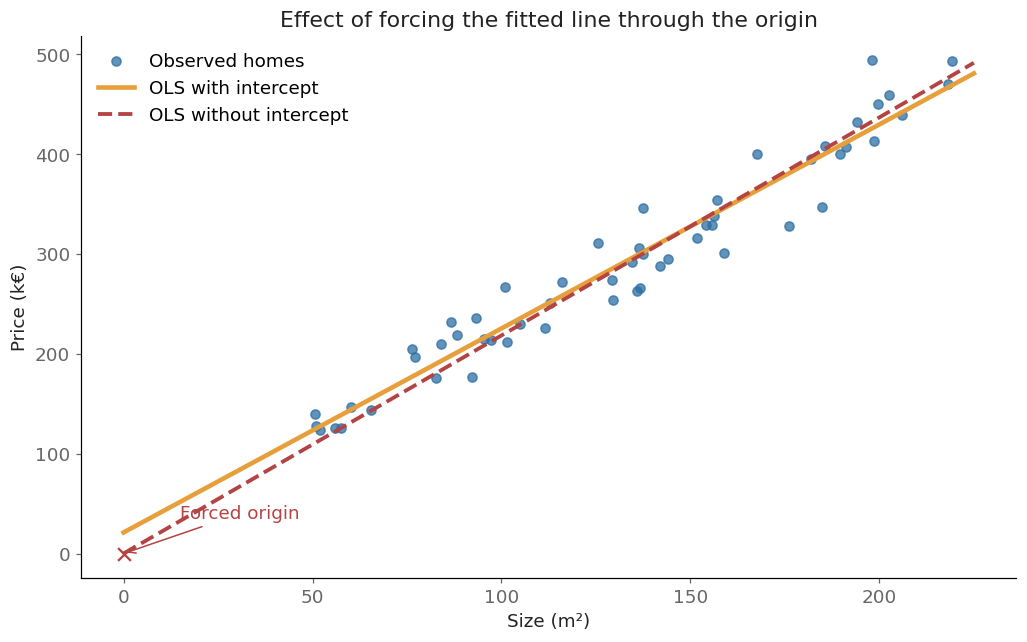

In [14]:
model_no_intercept = LinearRegression(fit_intercept=False)
model_no_intercept.fit(x.reshape(-1, 1), y)

y_hat_no_intercept = model_no_intercept.predict(x.reshape(-1, 1))
residuals_no_intercept = y - y_hat_no_intercept

intercept_comparison = pd.DataFrame({
    "Model": ["With intercept", "Without intercept"],
    "Intercept": [model_all.intercept_, 0.0],
    "Slope": [model_all.coef_[0], model_no_intercept.coef_[0]],
    "RSS": [np.sum(residuals**2), np.sum(residuals_no_intercept**2)],
    "Sum residuals": [residuals.sum(), residuals_no_intercept.sum()],
    "Sum x_i r_i": [np.sum(x * residuals), np.sum(x * residuals_no_intercept)],
})
display(intercept_comparison.round(4))

origin_grid = np.linspace(0, 225, 250)

fig, ax = plt.subplots()
ax.scatter(x, y, color=BLUE, alpha=0.75, label="Observed homes")
ax.plot(origin_grid, model_all.predict(origin_grid.reshape(-1, 1)), color=ORANGE, lw=3,
        label="OLS with intercept")
ax.plot(origin_grid, model_no_intercept.predict(origin_grid.reshape(-1, 1)), color=RED, lw=2.5,
        ls="--", label="OLS without intercept")
ax.scatter([0], [0], color=RED, marker="x", s=70, zorder=5)
ax.annotate("Forced origin", xy=(0, 0), xytext=(15, 35), color=RED,
            arrowprops={"arrowstyle": "->", "color": RED})
ax.set(
    title="Effect of forcing the fitted line through the origin",
    xlabel="Size (m²)",
    ylabel="Price (k€)",
)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_with_without_intercept.png", dpi=180)
plt.show()

# Parte II. Flujo completo de aprendizaje supervisado

Hasta ahora hemos utilizado toda la muestra para visualizar el ajuste. Esto explica cómo funciona OLS, pero no permite evaluar la predicción sobre observaciones nuevas.

Ahora reservamos un conjunto de test **antes** de estimar los coeficientes:

- **training set:** aprende $\widehat\beta_0$ y $\widehat\beta_1$;
- **test set:** evalúa el modelo ajustado sobre viviendas que no participaron en el aprendizaje.

No utilizaremos el conjunto de test para modificar el modelo.

Este ejemplo utiliza una única partición *holdout*. Su objetivo es completar correctamente el flujo de entrenamiento y evaluación, no comparar *holdout* con validación cruzada.

Training observations: 44
Test observations:     11
Disjoint indices: True


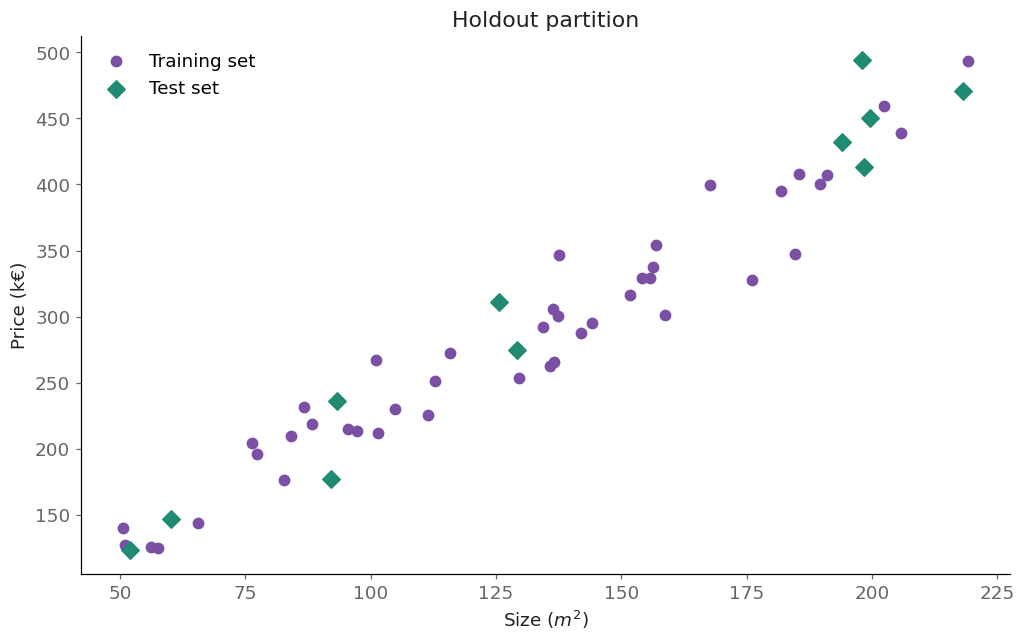

In [15]:
train_df, test_df = train_test_split(
    housing,
    test_size=0.20,
    random_state=42,
)

print(f"Training observations: {len(train_df)}")
print(f"Test observations:     {len(test_df)}")
print("Disjoint indices:", set(train_df.index).isdisjoint(set(test_df.index)))

fig, ax = plt.subplots()
ax.scatter(train_df["size_m2"], train_df["price_keuro"], color=PURPLE, s=45,
           label="Training set")
ax.scatter(test_df["size_m2"], test_df["price_keuro"], color=GREEN, s=65,
           marker="D", label="Test set")
ax.set(
    title="Holdout partition",
    xlabel="Size ($m^{2}$)",
    ylabel="Price (k€)",
)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_holdout_partition.png", dpi=180)
plt.show()

## 8. Ajuste exclusivamente sobre entrenamiento

Los coeficientes estimados ahora pueden diferir de los calculados con las 55 observaciones, porque el algoritmo solo utiliza el subconjunto de entrenamiento.

In [16]:
X_train = train_df[["size_m2"]].to_numpy()
y_train = train_df["price_keuro"].to_numpy()
X_test = test_df[["size_m2"]].to_numpy()
y_test = test_df["price_keuro"].to_numpy()

model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
train_residuals = y_train - train_pred
test_residuals = y_test - test_pred

print(f"Training estimate $\widehat\beta_0$ = {model.intercept_:.4f} k€")
print(f"Training estimate $\widehat\beta_1$ = {model.coef_[0]:.4f} k€/$m^{2}$")

metrics = pd.DataFrame({
    "Training": regression_metrics(y_train, train_pred),
    "Test": regression_metrics(y_test, test_pred),
})
display(metrics.round(3))

Training estimate $\widehateta_0$ = 28.4207 k€
Training estimate $\widehateta_1$ = 1.9681 k€/$m^2$


<>:14: SyntaxWarning: invalid escape sequence '\w'
<>:15: SyntaxWarning: invalid escape sequence '\w'
<>:14: SyntaxWarning: invalid escape sequence '\w'
<>:15: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_9773/1401563910.py:14: SyntaxWarning: invalid escape sequence '\w'
  print(f"Training estimate $\widehat\beta_0$ = {model.intercept_:.4f} k€")
/tmp/ipykernel_9773/1401563910.py:15: SyntaxWarning: invalid escape sequence '\w'
  print(f"Training estimate $\widehat\beta_1$ = {model.coef_[0]:.4f} k€/$m^{2}$")


,Training,Test
RSS (k€^2),22646.188,10231.389
MSE (k€^2),514.686,930.126
RMSE (k€),22.687,30.498
MAE (k€),17.814,22.973
$R^2$,0.939,0.946


### Interpretación de las métricas

- **RSS:** suma total de errores al cuadrado. Crece con el número de observaciones.
- **MSE:** promedio de los errores al cuadrado.
- **RMSE:** raíz de MSE. Tiene las mismas unidades que el target, k€.
- **MAE:** magnitud absoluta media del error, también en k€.
- **$R^2$:** compara el error del modelo con el error de predecir siempre la media del target del conjunto evaluado.

Para comparar entrenamiento y test con tamaños distintos, MSE, RMSE y MAE resultan más interpretables que RSS.

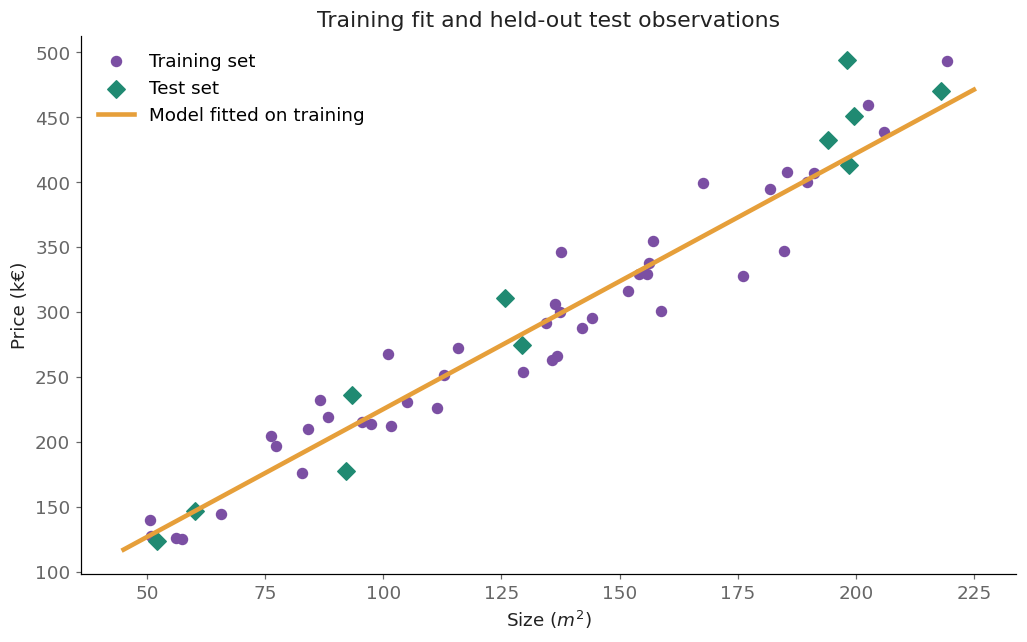

In [17]:
grid_predictions = model.predict(x_grid.reshape(-1, 1))

fig, ax = plt.subplots()
ax.scatter(X_train[:, 0], y_train, color=PURPLE, s=42, label="Training set")
ax.scatter(X_test[:, 0], y_test, color=GREEN, marker="D", s=65, label="Test set")
ax.plot(x_grid, grid_predictions, color=ORANGE, lw=3, label="Model fitted on training")
ax.set(
    title="Training fit and held-out test observations",
    xlabel="Size ($m^{2}$)",
    ylabel="Price (k€)",
)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_train_fit_and_test.png", dpi=180)
plt.show()

## 9. Diagnóstico de residuos

Un gráfico de residuos representa el error frente al predictor o frente a la predicción. Buscamos patrones sistemáticos que indiquen que la familia de modelos no está capturando parte de la estructura.

Las propiedades algebraicas de OLS se cumplen exactamente sobre entrenamiento. No están garantizadas sobre test, porque el modelo no eligió sus coeficientes utilizando esas observaciones.

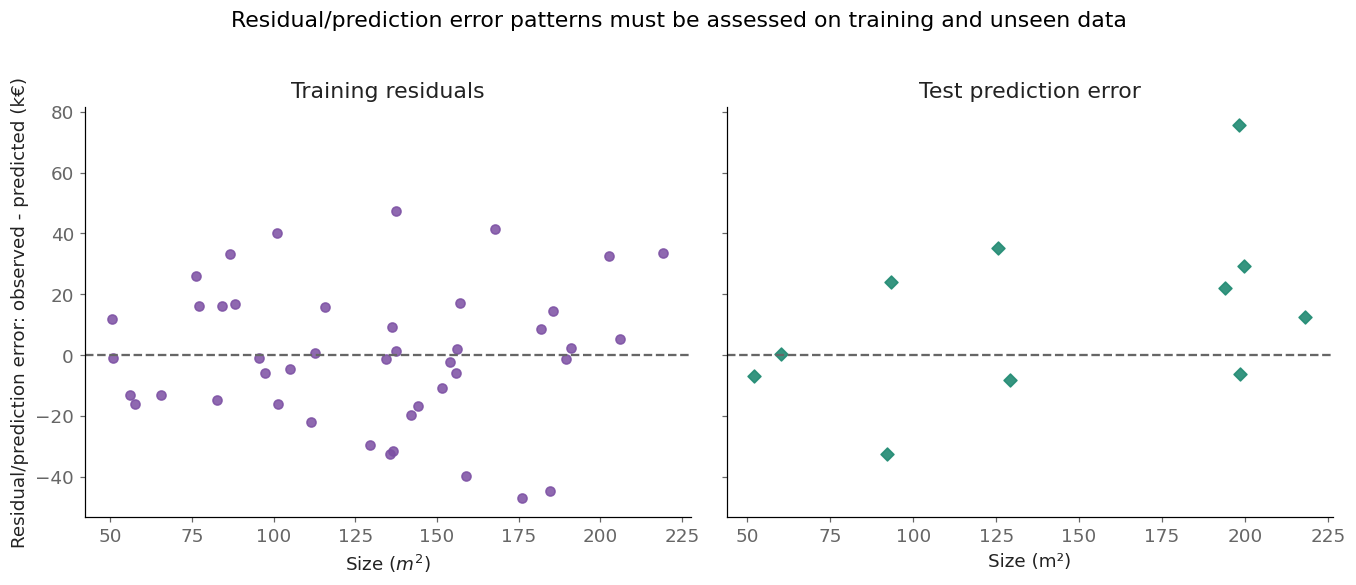

,Training,Test
Sum residuals,2.515321e-12,NaN
Mean residual,5.716639e-14,NaN
"Cov(size, residual)",9.487320e-14,NaN
Sum prediction error,NaN,144.957271
Mean prediction error,NaN,13.177934
"Cov(size, prediction error)",NaN,827.374033


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), sharey=True)

axes[0].scatter(X_train[:, 0], train_residuals, color=PURPLE, alpha=0.85)
axes[0].axhline(0, color=GREY, lw=1.5, ls="--")
axes[0].set(
    title="Training residuals",
    xlabel="Size ($m^{2}$)",
    ylabel="Residual/prediction error: observed - predicted (k€)",
)

axes[1].scatter(X_test[:, 0], test_residuals, color=GREEN, marker="D", alpha=0.9)
axes[1].axhline(0, color=GREY, lw=1.5, ls="--")
axes[1].set(
    title="Test prediction error",
    xlabel="Size (m²)",
)

fig.suptitle("Residual/prediction error patterns must be assessed on training and unseen data", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_train_test_residuals.png", dpi=180, bbox_inches="tight")
plt.show()

diagnostic_properties = pd.DataFrame({
    "Training": {
        "Sum residuals": train_residuals.sum(),
        "Mean residual": train_residuals.mean(),
        "Cov(size, residual)": np.cov(X_train[:, 0], train_residuals, ddof=1)[0, 1],
    },
    "Test": {
        "Sum prediction error": test_residuals.sum(),
        "Mean prediction error": test_residuals.mean(),
        "Cov(size, prediction error)": np.cov(X_test[:, 0], test_residuals, ddof=1)[0, 1],
    },
})
display(diagnostic_properties)

## 10. Predicción para una vivienda nueva

Una vez ajustado el modelo únicamente con entrenamiento, podemos predecir el precio de una vivienda no observada. Esta es una predicción puntual. No representa una garantía ni un intervalo de incertidumbre.

In [19]:
new_size = 140.0
new_prediction = model.predict(np.array([[new_size]]))[0]

print(f"New home size:       {new_size:.1f} $m^{2}$")
print(f"Predicted price:     {new_prediction:.2f} k€")
print(
    "Calculation:          "
    f"{model.intercept_:.2f} + {model.coef_[0]:.4f} x {new_size:.1f} "
    f"= {new_prediction:.2f} k€"
)

New home size:       140.0 $m^2$
Predicted price:     303.96 k€
Calculation:          28.42 + 1.9681 x 140.0 = 303.96 k€
